# Point-Mass Analytic Policy Gradient with TurboMPC

This example trains a small neural policy that outputs the cost weights of a constrained MPC controller for a 3D point-mass tracking task. The point mass follows a periodic zig-zag reference, and the policy is trained with analytic policy gradients through TurboMPC solver.

The notebook loads the pretrained policy weights and recorded outputs from `notebooks/pointmass_rl/outputs`. Set `RETRAIN = True` in the training section to reproduce the training run from scratch.

## 1. Environment and imports

This example uses TurboMPC's cuDSS solver backend. It is intended for an environment where the repository and CUDA extensions are already installed.

JAX x64 is enabled before importing JAX. At initialization, the tracking gradient through the MPC solve is small enough that float32 can round it to zero.

The path setup works when Jupyter is started anywhere inside this repository.

In [35]:
import sys
from pathlib import Path

from jax import config as _jax_cfg
_jax_cfg.update("jax_enable_x64", True)


def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "turbompc").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find the TurboMPC repository root. "
        "Start Jupyter from inside the repository, or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "examples" / "pointmass_rl"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in (REPO_ROOT, NOTEBOOK_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import time
import jax
import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Liberation Serif", "Times New Roman", "DejaVu Serif"]
mpl.rcParams["mathtext.fontset"] = "stix"

from turbompc.dynamics.linear_dynamics import LinearDynamics
from turbompc.problems.optimal_control_problem import OptimalControlProblem
from turbompc.solvers.turbompc_solver import BackwardBackend, ForwardBackend, TurboMPCSolver
from turbompc.utils.load_params import load_solver_params

from policy import init_policy, policy_apply
from optimizer import adam_init, adam_step

HERE = NOTEBOOK_DIR
print("repo root found:", REPO_ROOT.name)
print("jax:", jax.__version__, "devices:", jax.devices())

repo root found: diffmpc2
jax: 0.6.2 devices: [CudaDevice(id=0)]


## 2. Plant: 3D point mass

The state is $s = [x, y, z, v_x, v_y, v_z] \in \mathbb{R}^6$ and the control is $u = [f_x, f_y, f_z] \in \mathbb{R}^3$. The dynamics are a unit-mass double integrator with a per-axis thrust bound of $|u_i| \le 5$ N.

In [36]:
NX, NU = 6, 3
DT, MASS, F_BOUND, H_MPC = 0.1, 1.0, 5.0, 8
H_STAGES = H_MPC + 1  # MPC stages 0..H_MPC

A_dyn = jnp.zeros((NX, NX)).at[0:3, 3:6].set(jnp.eye(3))
B_dyn = jnp.zeros((NX, NU)).at[3:6, :].set(jnp.eye(3) / MASS)

dynamics = LinearDynamics({
    "num_states": NX,
    "num_controls": NU,
    "names_states": ["x", "y", "z", "vx", "vy", "vz"],
    "names_controls": ["fx", "fy", "fz"],
})

## 3. MPC problem and differentiable solver

The inner controller is an 8-step constrained MPC problem with box bounds on the control and loose state bounds. The neural policy overrides the state-tracking and control-effort weights at each closed-loop step.

The helper below loads solver defaults from the packaged YAML config rather than from test utilities, so the notebook stands on its own as an example.

In [37]:
def make_pointmass_params(mpc_horizon: int) -> dict:
    return {
        "horizon": mpc_horizon,
        "discretization_resolution": DT,
        "discretization_scheme": 0,  # Euler
        "initial_state": jnp.zeros(NX),
        "initial_guess_final_state": jnp.zeros(NX),
        "reference_state_trajectory": jnp.zeros((mpc_horizon + 1, NX)),
        "reference_control_trajectory": jnp.zeros((mpc_horizon + 1, NU)),
        "penalize_control_reference": False,
        "constrain_initial_control": False,
        "initial_control": jnp.zeros(NU),
        "rescale_optimization_variables": False,
        "state_rescaling_min": -jnp.ones(NX),
        "state_rescaling_max": jnp.ones(NX),
        "control_rescaling_min": -jnp.ones(NU),
        "control_rescaling_max": jnp.ones(NU),
        "weights_penalization_reference_state_trajectory": jnp.ones(NX),
        "weights_penalization_final_state": jnp.zeros(NX),
        "weights_penalization_control_squared": jnp.ones(NU),
        "weights_penalization_control_rate": jnp.zeros(NU),
        "state_min_bounds": -jnp.ones(NX) * 5.0,
        "state_max_bounds": jnp.ones(NX) * 5.0,
        "control_min_bounds": -jnp.ones(NU) * F_BOUND,
        "control_max_bounds": jnp.ones(NU) * F_BOUND,
        "use_slack_variables": False,
        "slack_penalization_weight": 0.0,
        "dynamics_state_dot_params": {
            "A": A_dyn,
            "B": B_dyn,
            "b": jnp.zeros((mpc_horizon + 1, NX)),
        },
    }


def make_turbompc_solver_params(*, tol: float = 1e-8, sqp_iters: int = 10, admm_max: int = 500) -> dict:
    params = load_solver_params("turbompc.yaml")
    params["tol_convergence"] = tol
    params["num_sqp_iteration_max"] = sqp_iters
    params["admm"]["eps_abs"] = tol
    params["admm"]["eps_rel"] = tol
    params["admm"]["max_iter"] = admm_max
    params["admm"]["pcg"]["max_iter"] = 500
    params["admm"]["pcg"]["tol_epsilon"] = 1e-12
    return params


mpc_params = make_pointmass_params(H_MPC)
ocp = OptimalControlProblem(dynamics=dynamics, params=mpc_params)
solver_params = make_turbompc_solver_params()

solver = TurboMPCSolver(
    ocp,
    params=solver_params,
    forward_backend=ForwardBackend.ADMM_FUSED_CUDSS,
    backward_backend=BackwardBackend.DIRECT_CUDSS_FFI,
)

## 4. Periodic zig-zag reference

The target is a six-waypoint 3D zig-zag. Each waypoint is held for four control steps. After the last waypoint, the reference reverses through the waypoint sequence, giving a 40-step cycle. Evaluation rolls out two full cycles.

In [38]:
A_X, SEGMENT_STEPS = 0.1, 4
WAYPOINTS = jnp.array([
    [+A_X, 0.00, 0.00],
    [-A_X, 0.05, 0.05],
    [+A_X, 0.10, 0.10],
    [-A_X, 0.15, 0.15],
    [+A_X, 0.10, 0.10],
    [-A_X, 0.05, 0.05],
])
REFERENCE_CYCLE = WAYPOINTS[jnp.array([0, 1, 2, 3, 4, 5, 4, 3, 2, 1])]
CYCLE_SEGMENTS = REFERENCE_CYCLE.shape[0]
CYCLE_STEPS = CYCLE_SEGMENTS * SEGMENT_STEPS
N_ROLL = 2 * CYCLE_STEPS


def pos_target_at_step(i):
    seg = (i // SEGMENT_STEPS) % CYCLE_SEGMENTS
    return REFERENCE_CYCLE[seg]

## 5. Policy: neural cost-weight schedule

The policy is a tiny MLP with input dimension 6 and output dimension 81. The output is reshaped to `(H_STAGES, 9)`: one row per MPC stage, with three position weights, three velocity weights, and three control-effort weights.

The final layer is initialized to zero, so the untrained network emits log-multipliers of zero. That makes the initial policy exactly match the fixed MPC prior below.

In [39]:
DEFAULT_POS_W = 1.0
DEFAULT_VEL_W = 1.0
DEFAULT_CTRL_W = 1e-3


def theta_to_weights(theta, state_obs):
    """Map state s in R^6 to positive time-varying MPC cost weights."""
    log_w = policy_apply(theta, state_obs).reshape(H_STAGES, 9)
    pos_w = DEFAULT_POS_W * jnp.exp(log_w[:, 0:3])
    vel_w = DEFAULT_VEL_W * jnp.exp(log_w[:, 3:6])
    ctrl_w = DEFAULT_CTRL_W * jnp.exp(log_w[:, 6:9])
    state_w = jnp.concatenate([pos_w, vel_w], axis=-1)
    return {
        "weights_penalization_reference_state_trajectory": state_w,
        "weights_penalization_control_squared": ctrl_w,
    }

## 6. Closed-loop rollout and APG loss

At each closed-loop step, the policy observes the current state and returns MPC weights. The MPC receives the next `H_MPC + 1` reference waypoints, solves the constrained problem, and applies the first control.

The loss compares post-control states to the phase-aligned reference. This avoids scoring the fixed initial state and gives the policy a gradient for the action it just applied.

In [40]:
H = 8  # training rollout horizon


def rollout(theta, s0, i0, n_steps):
    def step(s, k):
        gphase = i0 + k
        future_idx = gphase + jnp.arange(H_MPC + 1)
        future_pos = jax.vmap(pos_target_at_step)(future_idx)
        ref_state = jnp.concatenate([future_pos, jnp.zeros_like(future_pos)], axis=-1)
        weights = theta_to_weights(theta, s)
        problem_params = {
            **mpc_params,
            "initial_state": s,
            "reference_state_trajectory": ref_state,
        }
        sol = solver.solve(
            solver.initial_guess(problem_params),
            problem_params=problem_params,
            weights=weights,
        )
        u = sol.controls[0]
        s_next = s + DT * (A_dyn @ s + B_dyn @ u)
        return s_next, (s, u)

    final, (states, controls) = jax.lax.scan(step, s0, xs=jnp.arange(n_steps))
    return jnp.concatenate([states, final[None]], axis=0), controls


def apg_loss(theta, s0, i0):
    states, controls = rollout(theta, s0, i0, H)
    pos = states[1:, :3]
    tgt = jax.vmap(pos_target_at_step)(i0 + 1 + jnp.arange(H))
    track = jnp.sum((pos - tgt) ** 2, axis=-1).mean()
    ctrl = 0.001 * jnp.sum(controls ** 2, axis=-1).mean()
    return track + ctrl


def sample_init(rng):
    """Sample an initial condition near the reference at a random phase."""
    r_i, r_p, r_v = jax.random.split(rng, 3)
    i0 = jax.random.randint(r_i, (), 0, CYCLE_STEPS)
    p = pos_target_at_step(i0) + jax.random.uniform(r_p, (3,), minval=-0.03, maxval=0.03)
    v = jax.random.uniform(r_v, (3,), minval=-0.05, maxval=0.05)
    return jnp.concatenate([p, v]), i0


def batched_loss(theta, rng):
    rngs = jax.random.split(rng, 4)
    s0s, i0s = jax.vmap(sample_init)(rngs)
    return jax.vmap(lambda s, i: apg_loss(theta, s, i))(s0s, i0s).mean()

## 7. Deterministic evaluation metric

Evaluation starts on the reference at phase zero with zero velocity, rolls out two full reference cycles, and reports position RMSE. Unlike the training loss, this metric is deterministic.

In [41]:
def rmse_2cyc(theta):
    s0 = jnp.concatenate([pos_target_at_step(0), jnp.zeros(3)])
    states, _ = rollout(theta, s0, 0, N_ROLL)
    pos = states[1:, :3]
    tgt = jax.vmap(pos_target_at_step)(1 + jnp.arange(N_ROLL))
    return float(jnp.sqrt(jnp.mean(jnp.sum((pos - tgt) ** 2, axis=-1))))

## 8. Train or load pretrained weights

Keep `RETRAIN = False` for a quick run that loads the pretrained checkpoint from `notebooks/pointmass_rl/outputs`. Set it to `True` to regenerate `pointmass_apg_500_theta.npz` and `pointmass_apg_500.csv`.

The included checkpoint and CSV correspond to the back-and-forth reference cycle defined above.

Training uses the differentiable MPC solve inside the rollout and can take tens of minutes depending on GPU and solver build.

In [42]:
RETRAIN = True
N_STEPS, LR, EVAL_EVERY = 500, 3e-3, 10

CSV_PATH = OUTPUT_DIR / "pointmass_apg_500.csv"
THETA_PATH = OUTPUT_DIR / "pointmass_apg_500_theta.npz"


def save_theta(path, theta):
    np.savez(path, **{f"leaf_{i}": np.asarray(v) for i, v in enumerate(jax.tree.leaves(theta))})


def load_theta(path, obs_dim=6, out_dim=H_STAGES * 9):
    template = init_policy(jax.random.PRNGKey(0), obs_dim=obs_dim, out_dim=out_dim)
    leaves, treedef = jax.tree.flatten(template)
    arrays = np.load(path)
    return jax.tree.unflatten(
        treedef,
        [jnp.asarray(arrays[f"leaf_{i}"]) for i in range(len(leaves))],
    )

if RETRAIN:
    theta = init_policy(jax.random.PRNGKey(0), obs_dim=6, out_dim=H_STAGES * 9)
    opt_state = adam_init(theta)
    loss_and_grad = jax.value_and_grad(batched_loss)
    
    adam_step = jax.jit(adam_step)
    loss_and_grad = jax.jit(loss_and_grad)

    print(f"policy: 6 -> 8 -> {H_STAGES * 9}; batch=4, lr={LR}, steps={N_STEPS}")
    rmse0 = rmse_2cyc(theta)
    print(f"step 0: eval RMSE = {rmse0:.4e} m (untrained)")
    rows = [(0, None, rmse0, None, 0.0)]

    t_wall0 = time.time()
    rng_data = jax.random.PRNGKey(42)
    for step in range(N_STEPS):
        rng_data, sub = jax.random.split(rng_data)
        t0 = time.time()
        loss_value, grad = loss_and_grad(theta, sub)
        theta, opt_state = adam_step(theta, grad, opt_state, lr=LR)
        jax.block_until_ready((loss_value, grad, theta, opt_state))
        step_time = time.time() - t0
        grad_norm = float(jnp.sqrt(sum(jnp.sum(v ** 2) for v in jax.tree.leaves(grad))))
        if (step + 1) % EVAL_EVERY == 0 or step == 0:
            rmse_t = rmse_2cyc(theta)
            print(
                f"step {step + 1:>3}: "
                f"loss={float(loss_value):.3e}, "
                f"eval RMSE={rmse_t:.4e} m, "
                f"|grad|={grad_norm:.2e}, "
                f"time={step_time:.3f}s"
            )
            rows.append((step + 1, float(loss_value), rmse_t, grad_norm, step_time))
        else:
            rows.append((step + 1, float(loss_value), None, grad_norm, step_time))

    print(f"total wall-clock: {(time.time() - t_wall0) / 60:.1f} min")
    save_theta(THETA_PATH, theta)

    import csv

    with open(CSV_PATH, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["step", "train_loss", "eval_rmse", "grad_norm", "step_time"])
        for step, loss_value, rmse_value, grad_norm, step_time in rows:
            writer.writerow([
                step,
                "" if loss_value is None else f"{loss_value:.6e}",
                "" if rmse_value is None else f"{rmse_value:.6e}",
                "" if grad_norm is None else f"{grad_norm:.6e}",
                f"{step_time:.3f}",
            ])
else:
    if not THETA_PATH.exists():
        raise FileNotFoundError(
            f"Missing pretrained weights: {THETA_PATH}. Set RETRAIN = True to generate them."
        )
    theta = load_theta(THETA_PATH)
    print(f"loaded pretrained theta: {THETA_PATH.relative_to(REPO_ROOT)}")
    print(f"learning curve CSV: {CSV_PATH.relative_to(REPO_ROOT)}")

policy: 6 -> 8 -> 81; batch=4, lr=0.003, steps=500
step 0: eval RMSE = 1.2022e-01 m (untrained)
step   1: loss=2.080e-02, eval RMSE=1.2012e-01 m, |grad|=1.19e-03, time=12.710s
step  10: loss=2.191e-02, eval RMSE=1.1907e-01 m, |grad|=2.27e-03, time=0.025s
step  20: loss=2.203e-02, eval RMSE=1.1754e-01 m, |grad|=3.18e-03, time=0.025s
step  30: loss=2.093e-02, eval RMSE=1.1548e-01 m, |grad|=3.10e-03, time=0.025s
step  40: loss=2.194e-02, eval RMSE=1.1270e-01 m, |grad|=4.84e-03, time=0.031s
step  50: loss=1.666e-02, eval RMSE=1.0911e-01 m, |grad|=5.44e-03, time=0.034s
step  60: loss=1.748e-02, eval RMSE=1.0444e-01 m, |grad|=5.40e-03, time=0.039s
step  70: loss=1.548e-02, eval RMSE=9.8964e-02 m, |grad|=4.29e-03, time=0.041s
step  80: loss=1.631e-02, eval RMSE=9.3534e-02 m, |grad|=1.36e-03, time=0.047s
step  90: loss=1.692e-02, eval RMSE=8.9871e-02 m, |grad|=1.71e-03, time=0.046s
step 100: loss=1.596e-02, eval RMSE=8.7845e-02 m, |grad|=1.87e-03, time=0.045s
step 110: loss=1.126e-02, eval RMS

## 9. Learning curve

The plot shows deterministic two-cycle evaluation RMSE over training. The untrained horizontal baseline is the fixed MPC prior produced by the zero-initialized policy.

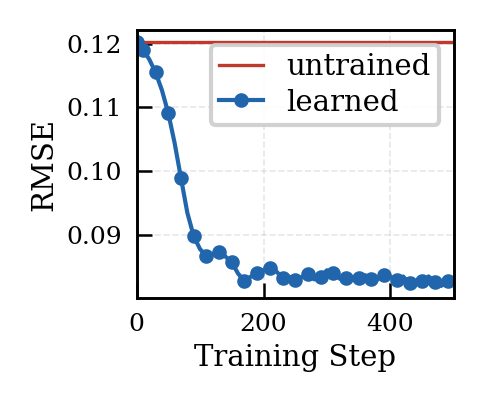

initial eval RMSE: 1.2022e-01 m
final eval RMSE:   8.3259e-02 m
best eval RMSE:    8.2084e-02 m at step 480
relative change:   30.7%


In [43]:
import csv
import numpy as np
from IPython.display import Image, display

steps, rmses = [], []
with open(CSV_PATH) as f:
    for row in csv.DictReader(f):
        if row["eval_rmse"]:
            steps.append(int(row["step"]))
            rmses.append(float(row["eval_rmse"]))

steps = np.asarray(steps)
rmses = np.asarray(rmses)

display(Image(filename=str(OUTPUT_DIR / "pointmass_apg_500_curve.png")))

print(f"initial eval RMSE: {rmses[0]:.4e} m")
print(f"final eval RMSE:   {rmses[-1]:.4e} m")
print(f"best eval RMSE:    {rmses.min():.4e} m at step {int(steps[rmses.argmin()])}")
print(f"relative change:   {(rmses[0] - rmses[-1]) / rmses[0] * 100:.1f}%")

## 10. Closed-loop trajectory

This figure compares the reference, the untrained MPC prior, and the learned policy over two reference cycles.

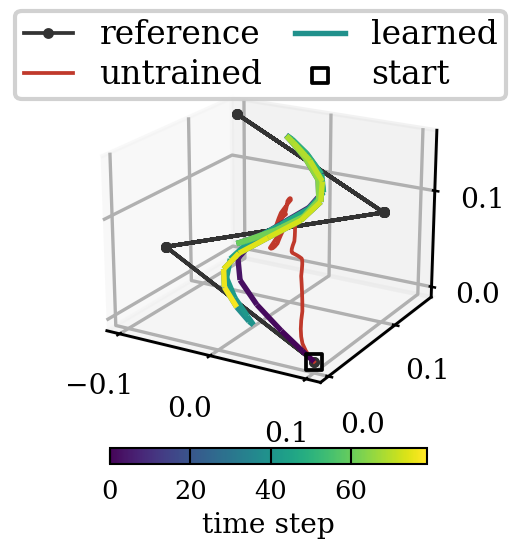

In [44]:
from IPython.display import Image, display

display(Image(filename=str(OUTPUT_DIR / "pointmass_trajectory_3d.png")))

## 11. Results and reproduction notes

With the back-and-forth reference cycle, the learned policy reduces the deterministic two-cycle tracking RMSE from about `1.20e-1 m` to about `8.33e-2 m` after 500 Adam steps. The best evaluation point in the recorded run is about `8.21e-2 m` at step 480.

The recorded GPU run took about 3 minutes on an RTX 5090.

From the repository root, the same experiment can also be run as a script:

```bash
XLA_PYTHON_CLIENT_PREALLOCATE=false PYTHONPATH=. python notebooks/pointmass_rl/pointmass_rl.py
```